<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102193 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country code                    102468 non-null  object 
 11  instant_bookable                102494 non-null  object 
 12  cancellation_pol

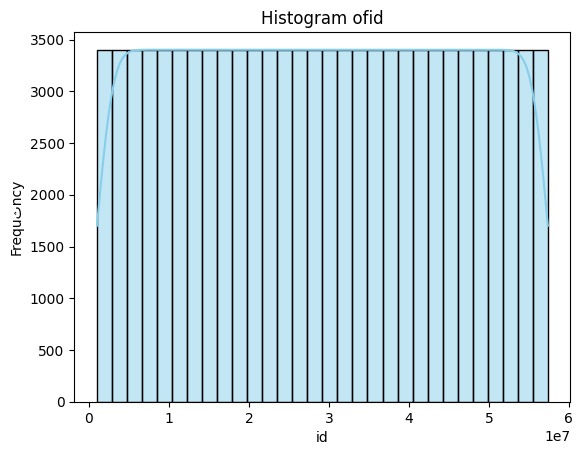

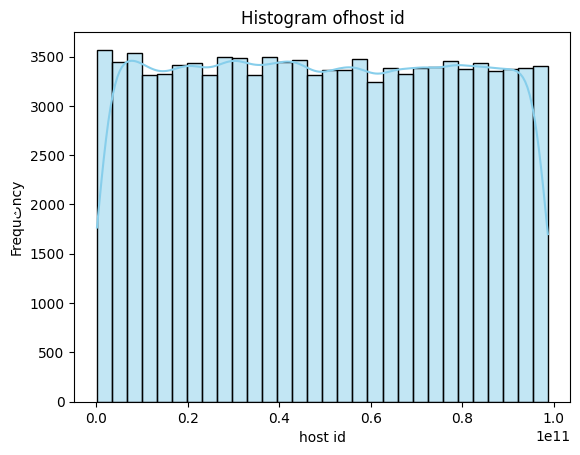

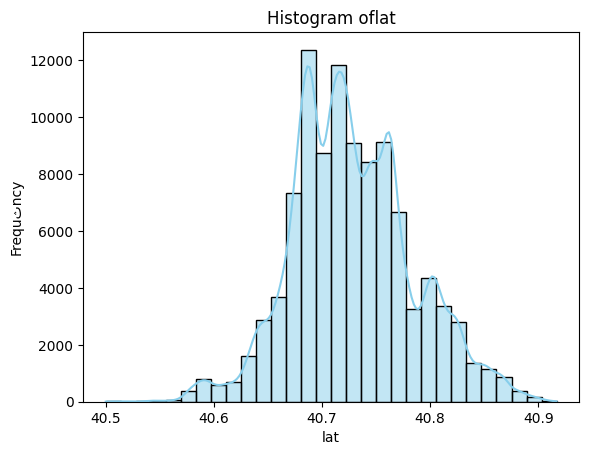

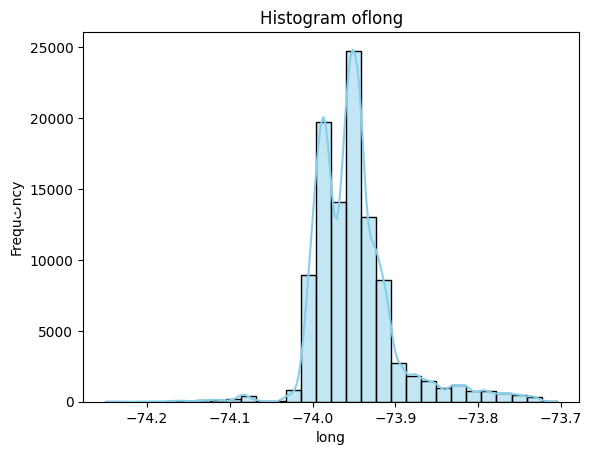

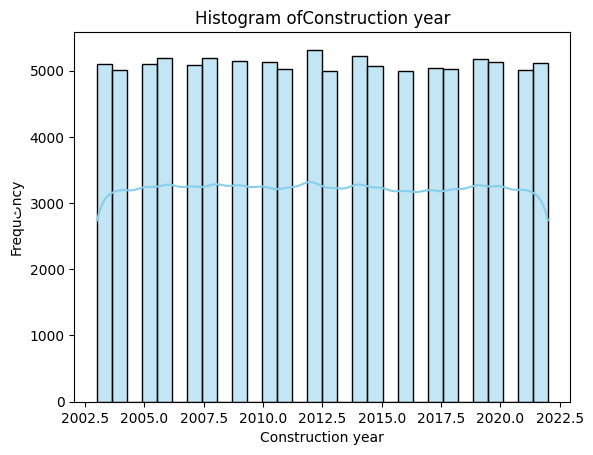

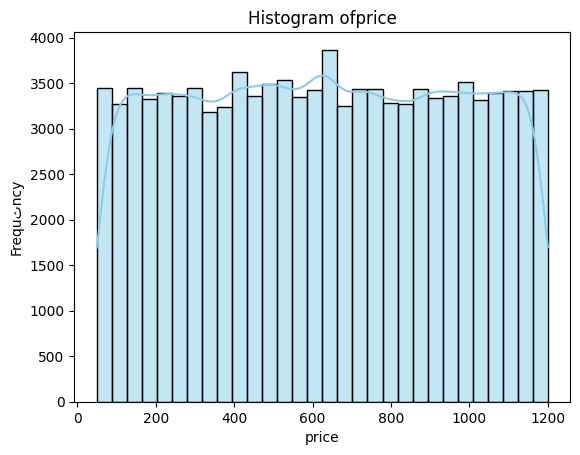

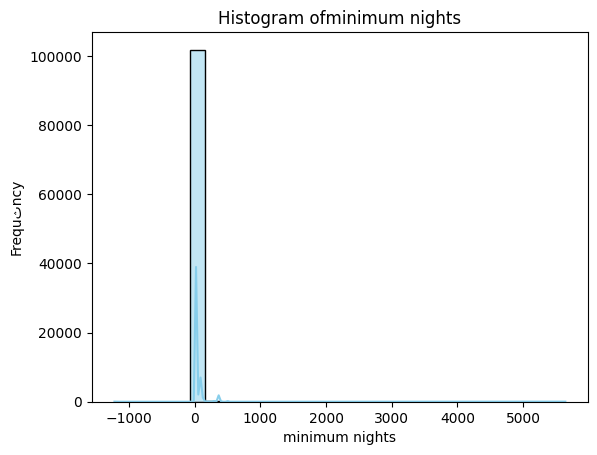

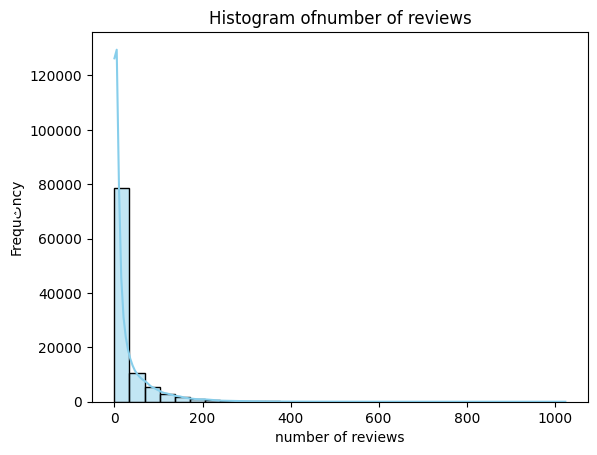

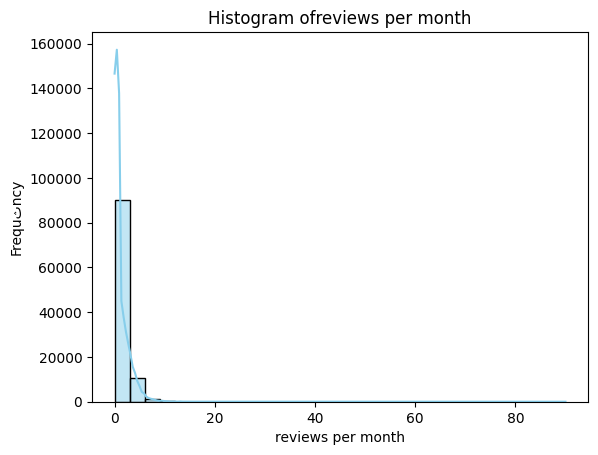

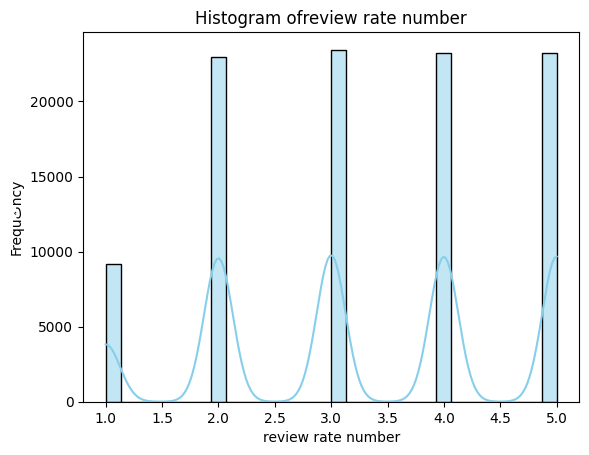

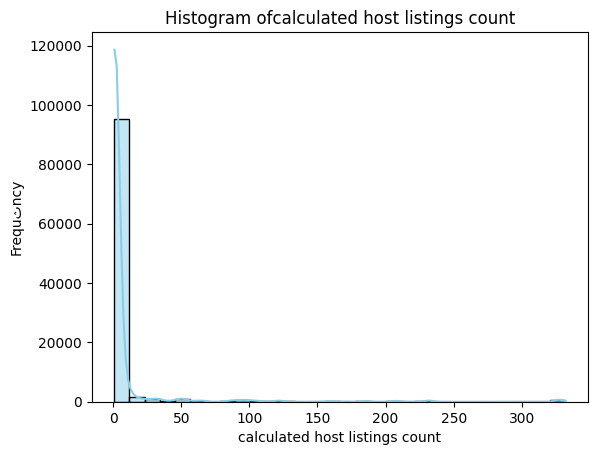

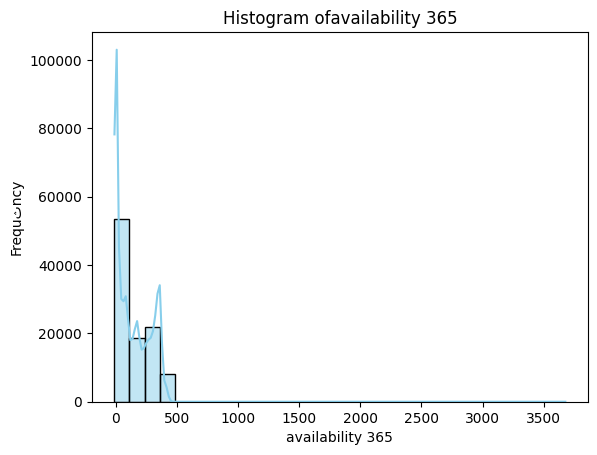

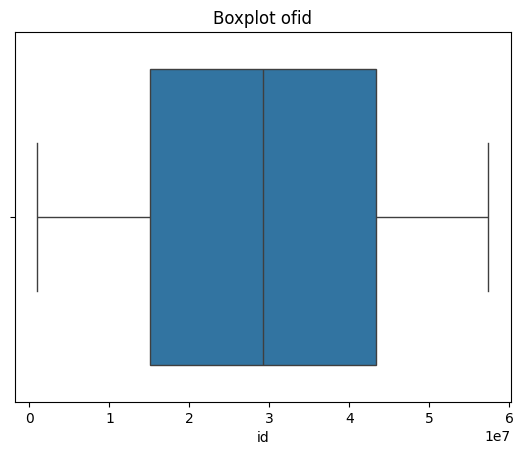

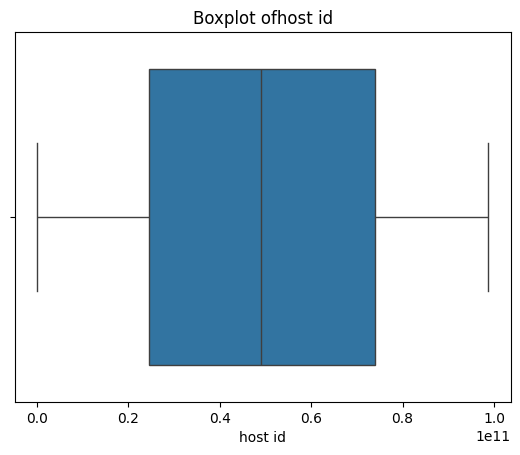

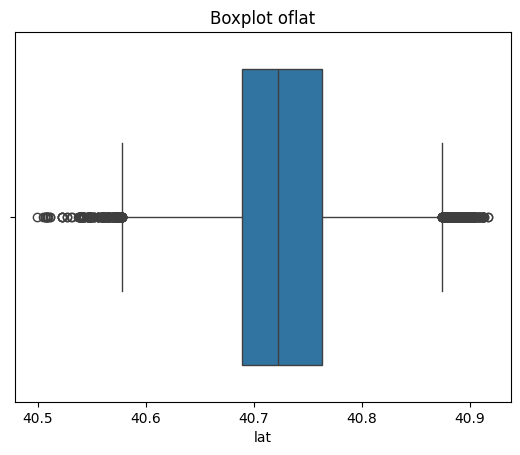

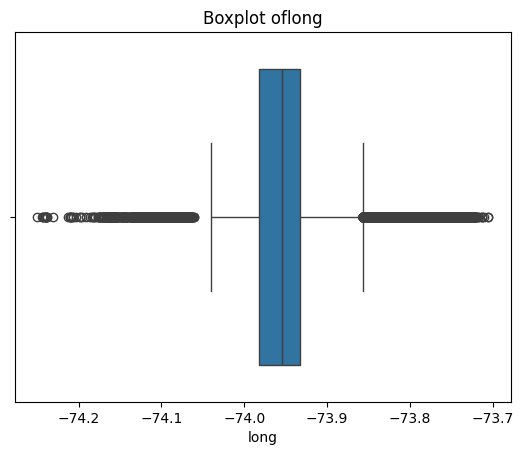

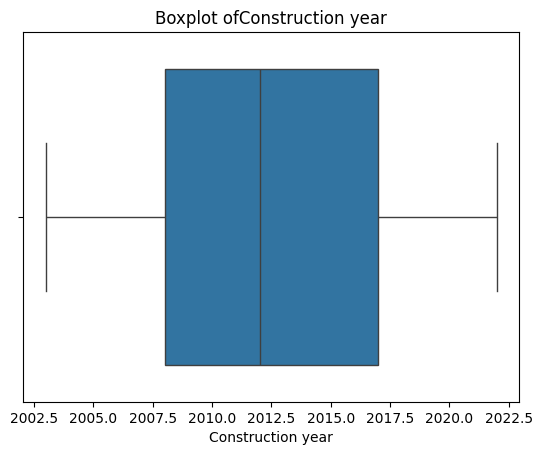

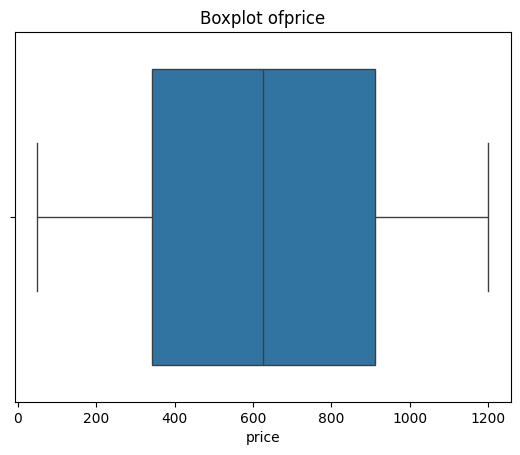

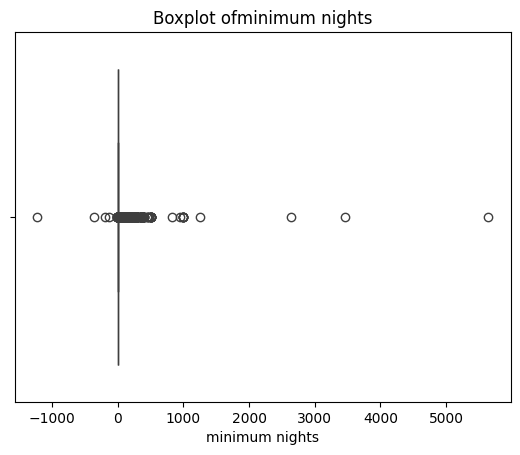

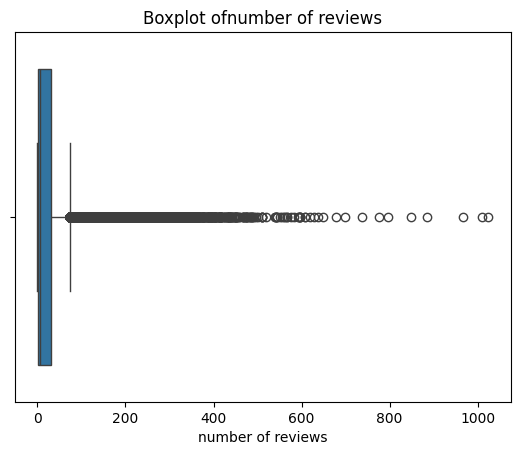

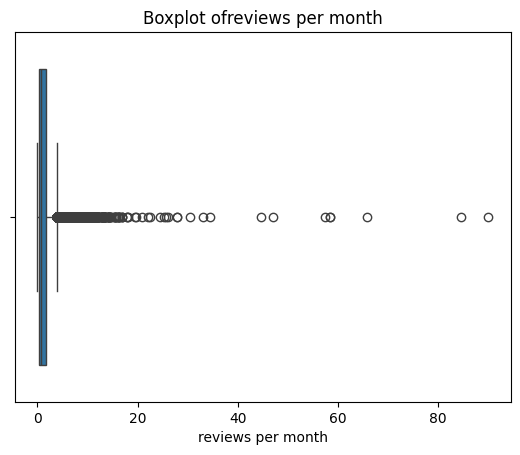

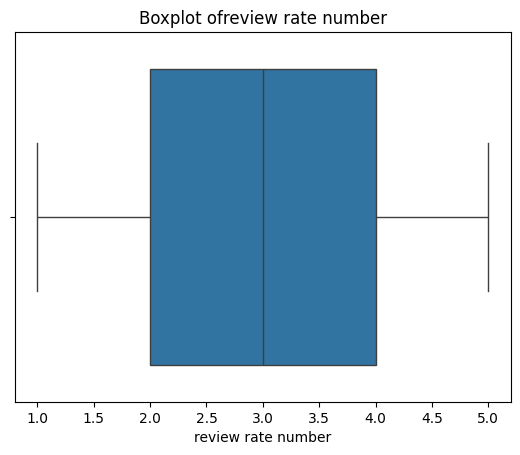

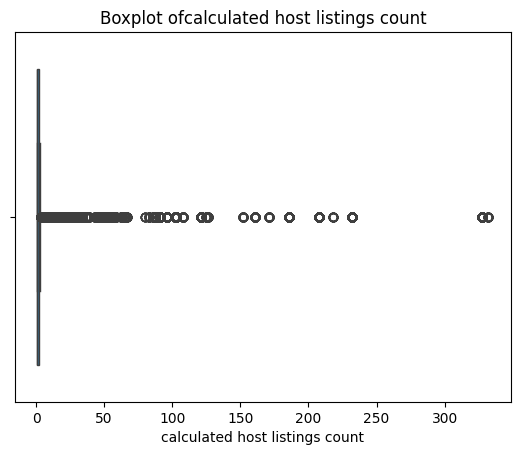

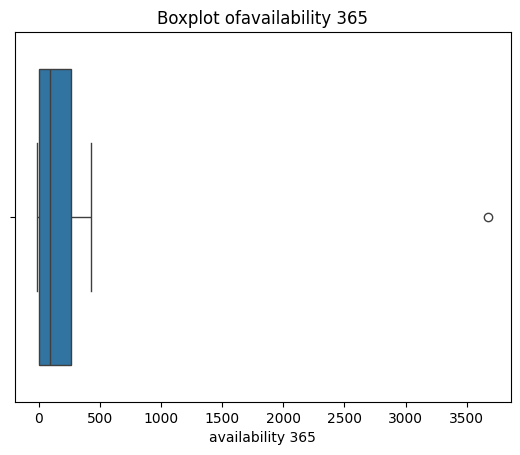

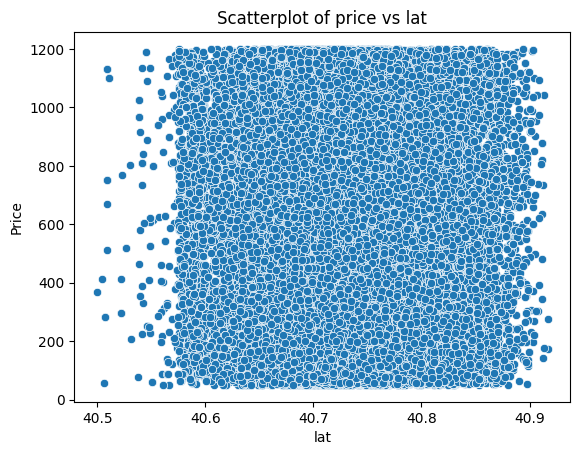

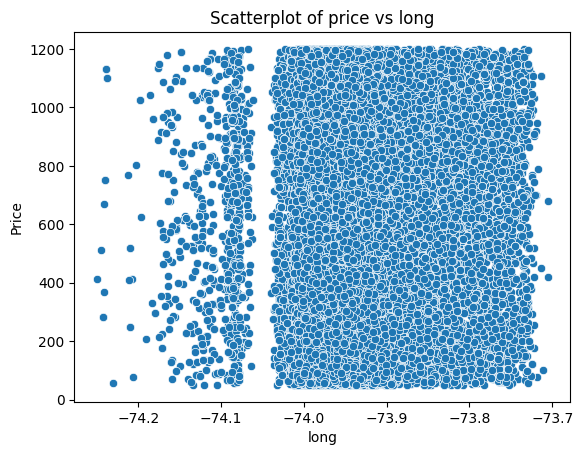

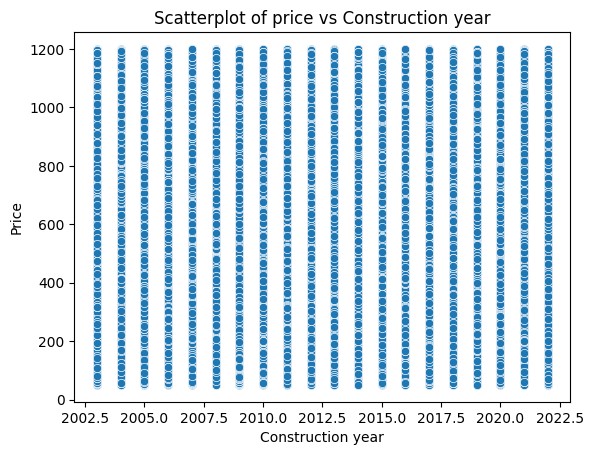

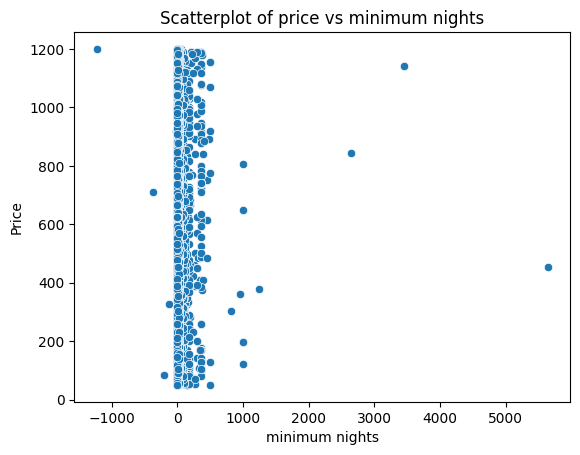

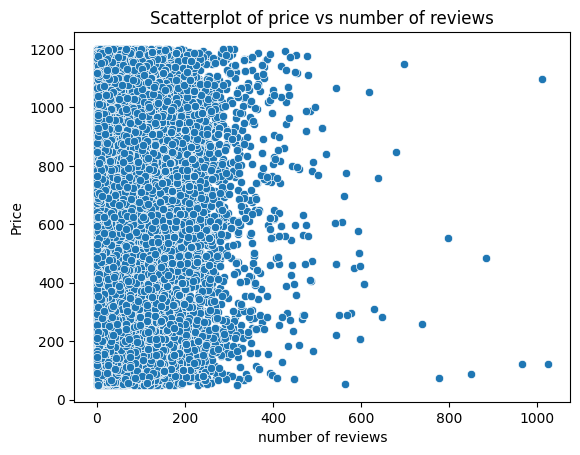

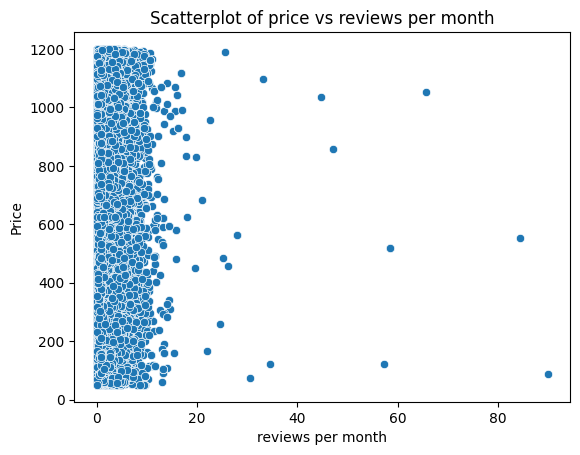

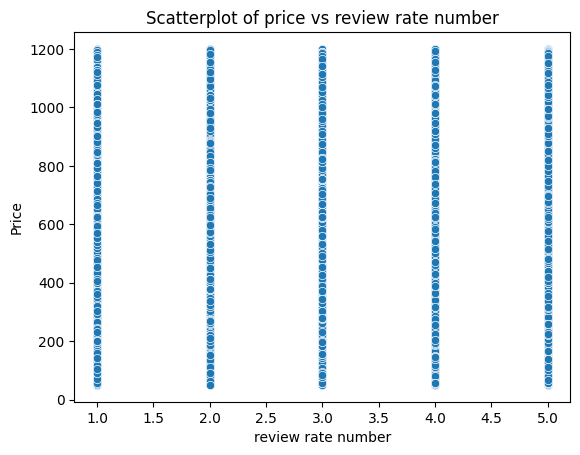

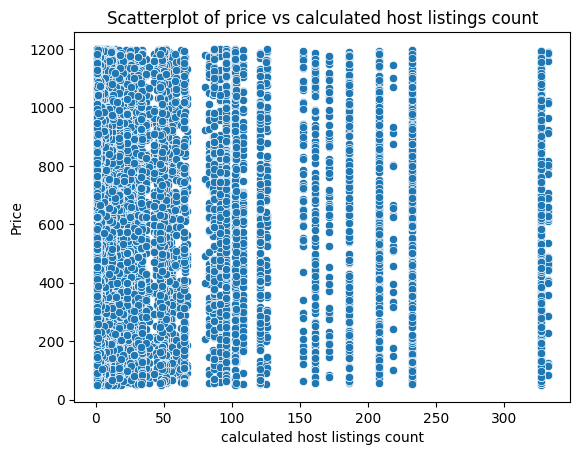

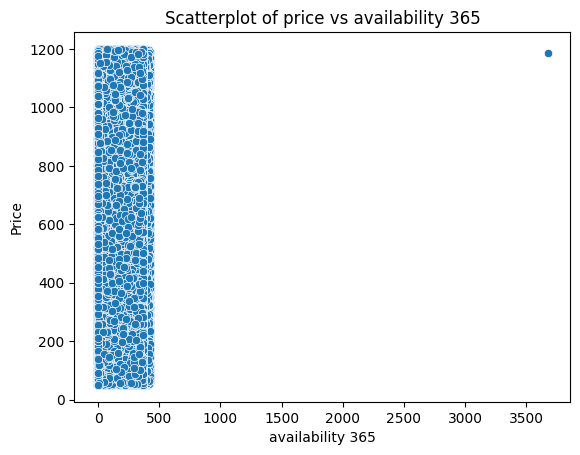

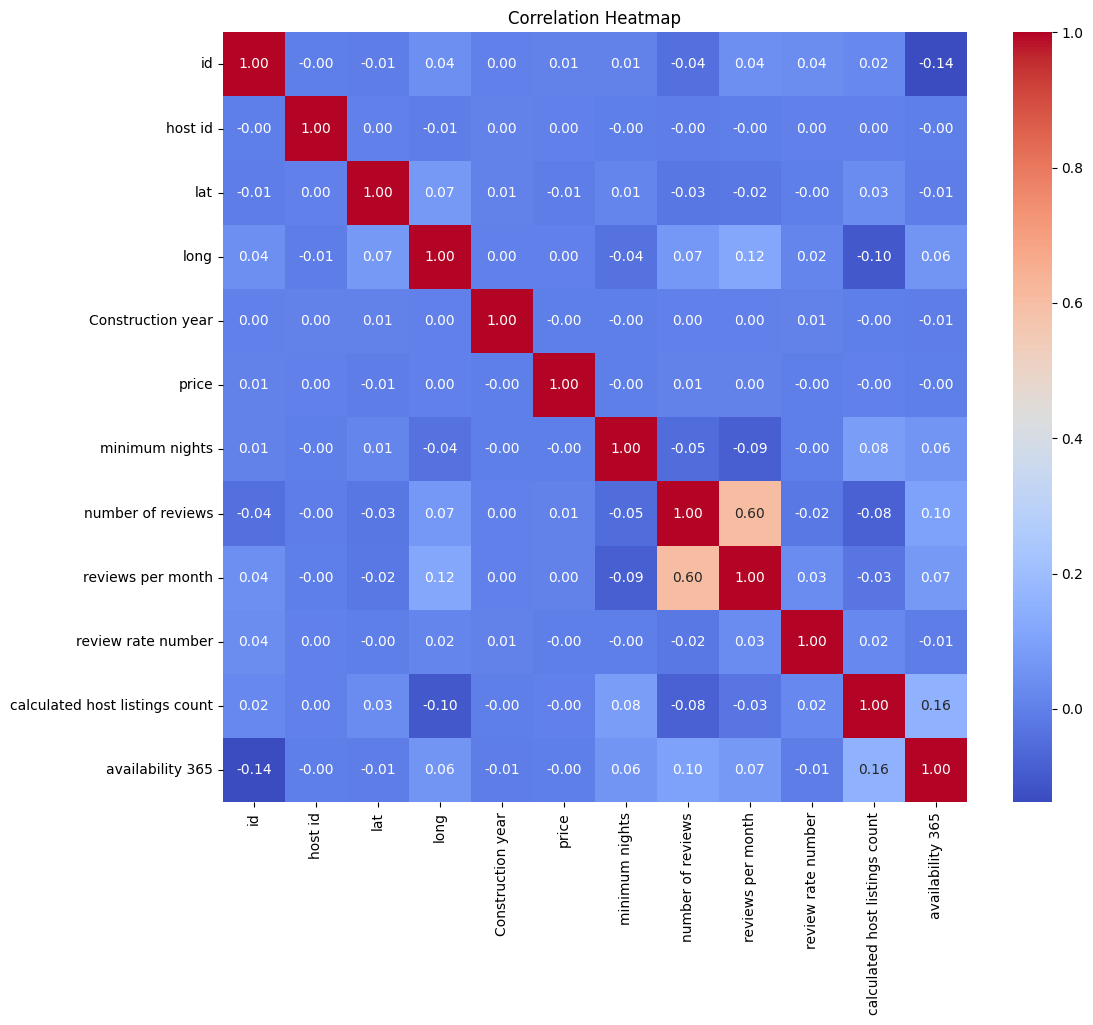

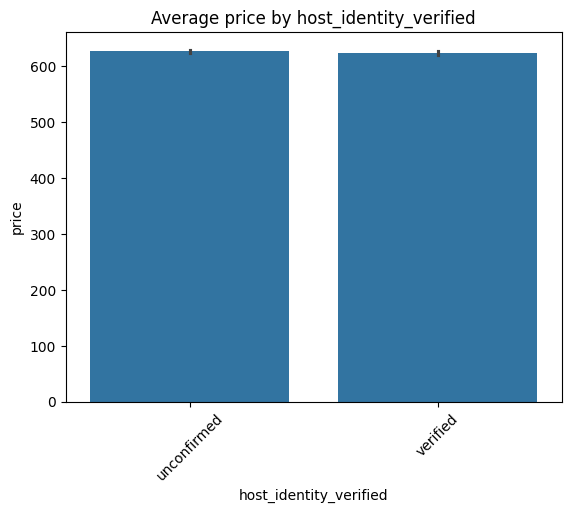

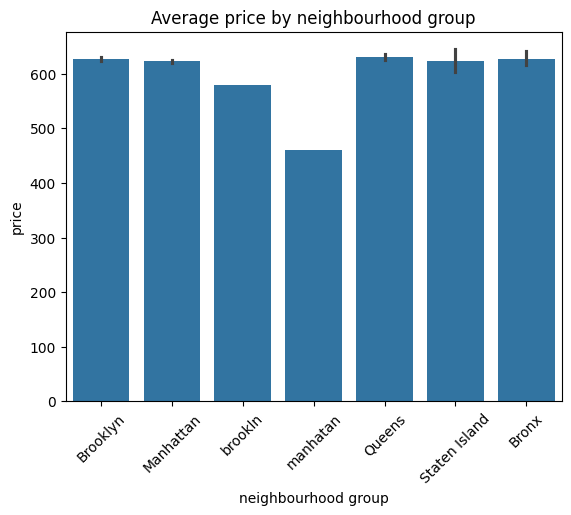

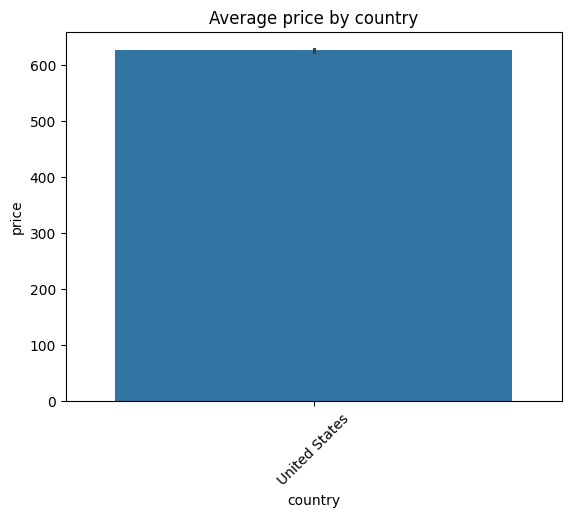

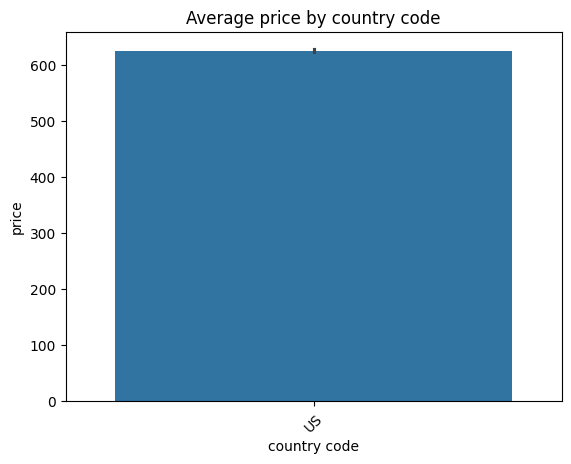

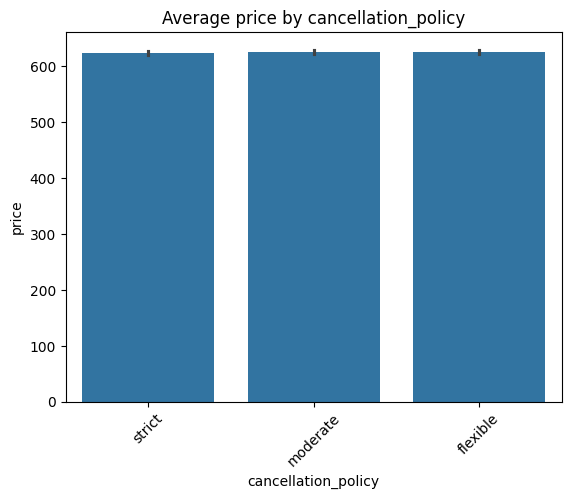

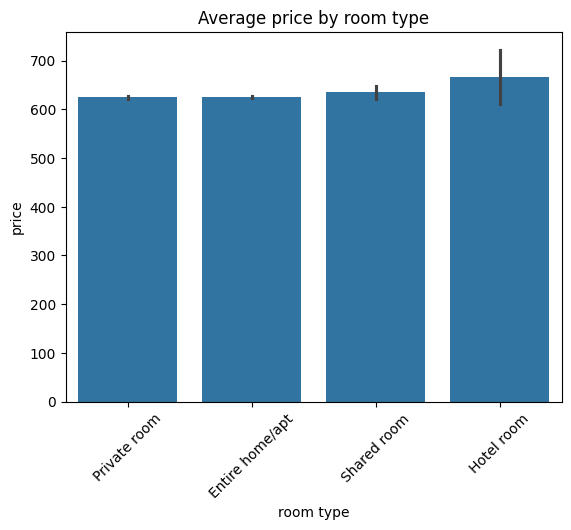

id -> Outliers: 0
host id -> Outliers: 0
lat -> Outliers: 909
long -> Outliers: 6498
Construction year -> Outliers: 0
price -> Outliers: 0
minimum nights -> Outliers: 18251
number of reviews -> Outliers: 11696
reviews per month -> Outliers: 7099
review rate number -> Outliers: 0
calculated host listings count -> Outliers: 17702
availability 365 -> Outliers: 1
minimum nights 86.77615440707032
number of reviews 3.8420519439054264
reviews per month 7.601488874608063
calculated host listings count 7.2316257385936416
minimum nights -> Outliers before capping: 18251
number of reviews -> Outliers before capping: 11696
reviews per month -> Outliers before capping: 7099
calculated host listings count -> Outliers before capping: 17702


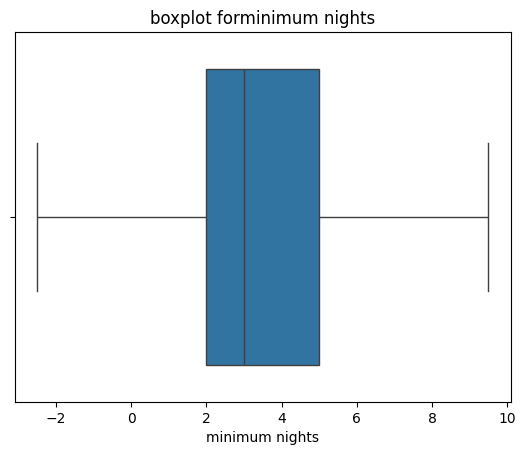

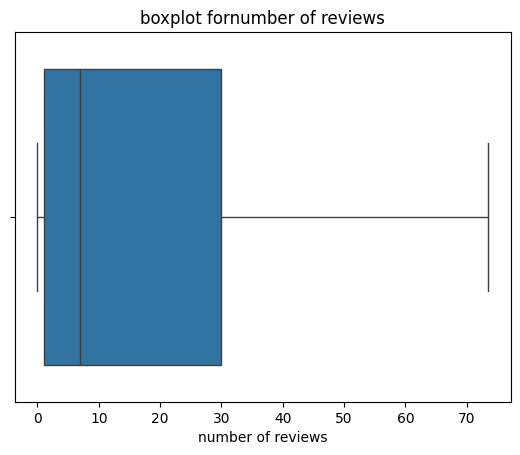

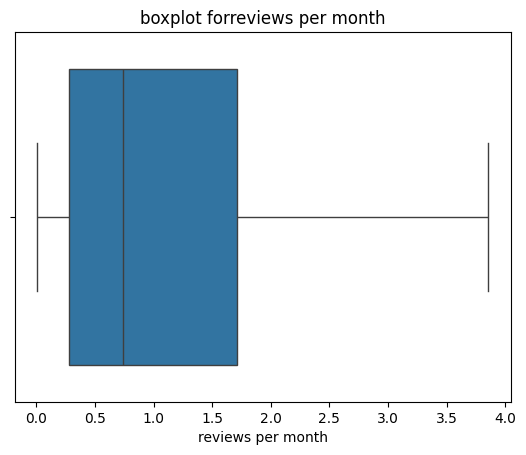

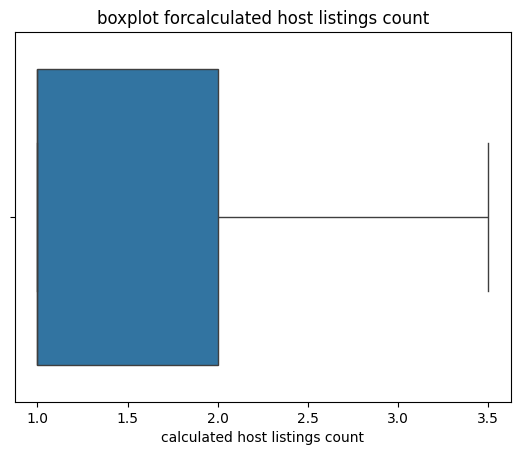

Column: NAME
NAME
Home away from home                                 0.002773
Water View King Bed Hotel Room                      0.000294
Hillside Hotel                                      0.000294
Brooklyn Apartment                                  0.000265
New york Multi-unit building                        0.000265
                                                      ...   
West Village Nest - Superhost                       0.000010
Wonderful Guest Bedroom in Manhattan for SINGLES    0.000010
Lovely Room 1, Garden, Best Area, Legal rental      0.000010
Central Manhattan/near Broadway                     0.000010
Beautiful 1br on Upper West Side                    0.000010
Name: proportion, Length: 61281, dtype: float64
----------------------------------------
Column: host_identity_verified
host_identity_verified
unconfirmed    0.501999
verified       0.498001
Name: proportion, dtype: float64
----------------------------------------
Column: host name
host name
Michael           

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import SMOTE

dt = pd.read_csv('/content/Airbnb_Open_Data.csv')
dt.shape
dt.info()
df=dt.drop_duplicates()
print(df.duplicated().sum())
df = df.drop(columns=['house_rules', 'license', 'last review'])
df['price'] = df['price'].str.replace('$','',regex = False).str.replace(',','',regex = False).astype(float)

#Cleaning numerical by median values
for col in [ 'lat', 'long', 'Construction year','price', 'minimum nights',
                'number of reviews', 'reviews per month', 'review rate number',
                'calculated host listings count', 'availability 365']:
                df[col].fillna(df[col].median(), inplace=True)

#Cleaning categorical values by mode value
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)
print(df.isnull().sum())
print(df.shape)

'''print(df.head())
print(df.shape)
df.isnull().sum()
df.isnull().sum()/data.shape[0]*100
df.duplicated().sum()

for i in df.select_dtypes(include="object").columns:
  print(df[i].value_counts())
  print("***"*10)

df.describe().T
df.describe(include="object")'''

#Histogram
for i in df.select_dtypes(include = "number").columns:
  sns.histplot(data=df ,x=i , bins=30 , kde=True , color='skyblue')
  plt.title(f'Histogram of {i}')
  plt.xlabel(i)
  plt.ylabel('Frequثncy')
  plt.show()

#Boxplot
for i in df.select_dtypes(include = "number").columns:
  sns.boxplot(data = df , x = i)
  plt.title(f'Boxplot of{i}')
  plt.show()

#print(df.select_dtypes(include="number").columns)

#Scatterplot , id , host id unique to every one so i removed it
for i in [ 'lat', 'long', 'Construction year',
          'minimum nights', 'number of reviews', 'reviews per month',
       'review rate number', 'calculated host listings count',
       'availability 365'] :
       sns.scatterplot(data = df , x = i , y='price')
       plt.title(f'Scatterplot of price vs {i}')
       plt.xlabel(i)
       plt.ylabel('Price')
       plt.show()

#Heatmap
s=df.select_dtypes(include="number").corr()
plt.figure(figsize=(12,10))
sns.heatmap(s,annot=True,cmap='coolwarm' , fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

#Barchart
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    if df[col].nunique() <= 10:
        plt.figure()
        sns.barplot(data=df, x=col, y='price', estimator='mean')
        plt.xticks(rotation=45)
        plt.title(f'Average price by {col}')
        plt.show()

'''
data.to_csv('Airbnb_cleaned.csv', index=False)
from google.colab import files
files.download('Airbnb_cleaned.csv')'''

#show columns that have outliers

numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col} -> Outliers: {outliers.shape[0]}")

#DETECT outliers
#IQR method
num_col = ['minimum nights','number of reviews', 'reviews per month','calculated host listings count']
for col in num_col:
  print(col, df[col].skew())

for col in num_col:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3-Q1
  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR
  outliers_count = df[(df[col] < lower) | (df[col] > upper)].shape[0]
  print(f"{col} -> Outliers before capping: {outliers_count}")
  #outliers fix
  df[col] = np.where(df[col] > upper, upper, np.where(df[col] < lower, lower, df[col]))

#Boxplot after removing outliers
for col in num_col:
  sns.boxplot(x=df[col])
  plt.title(f'boxplot for{col}')
  plt.show()

# Z-core methods another method
'''for col in num_col:
  mean = df[col].mean()
  std = df[col].std()

  upper = mean + 3 * std
  lower = mean - 3 * std

  z_score = np.abs(stats.zscore(df[col]))
  outliers_count = np.sum(z_score > 3)
  print(f"{col} -> Outliers by Z-score: {outliers_count}")

  df[col] = np.where(df[col] > upper , upper , np.where(df[col] < lower , lower , df[col]))

for col in num_col:
  sns.boxplot(x=df[col])
  plt.title(f'Boxplot for {col}')
  plt.show()
'''
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"Column: {col}")
    print(df[col].value_counts(normalize=True))
    print("-"*40)
# اختيار الأعمدة categorical
categorical_cols = df.select_dtypes(include='object').columns

# دالة للكشف عن imbalance
def detect_imbalance(df, threshold_low=0.05, threshold_high=0.9):
    imbalance_report = {}
    for col in categorical_cols:
        proportions = df[col].value_counts(normalize=True)
        # أي عمود فيه فئة قليلة أو كبيرة جدًا
        if (proportions < threshold_low).any() or (proportions > threshold_high).any():
            imbalance_report[col] = proportions
    return imbalance_report

imbalanced_cols = detect_imbalance(df)
for col, prop in imbalanced_cols.items():
    print(f"\nColumn: {col}")
    print(prop)


features = ['price', 'minimum nights', 'number of reviews', 'reviews per month',
            'review rate number', 'calculated host listings count', 'availability 365']

X = df[features]
y = df['room type']


le = LabelEncoder()
y_encoded = le.fit_transform(y)


print("Class Distribution:")
print(df['room type'].value_counts())
print(df['room type'].value_counts(normalize=True))


X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)


clf_base = RandomForestClassifier(random_state=42)
clf_base.fit(X_train, y_train)
y_pred_base = clf_base.predict(X_test)
acc_base = accuracy_score(y_test, y_pred_base)

print("\n=== Baseline Performance ===")
print(classification_report(y_test, y_pred_base, target_names=le.classes_))


smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

clf_smote = RandomForestClassifier(random_state=42)
clf_smote.fit(X_res, y_res)
y_pred_smote = clf_smote.predict(X_test)
acc_smote = accuracy_score(y_test, y_pred_smote)

print("\n=== SMOTE Performance ===")
print(classification_report(y_test, y_pred_smote, target_names=le.classes_))


clf_weight = RandomForestClassifier(class_weight='balanced', random_state=42)
clf_weight.fit(X_train, y_train)
y_pred_weight = clf_weight.predict(X_test)
acc_weight = accuracy_score(y_test, y_pred_weight)

print("\n=== Class Weight Performance ===")
print(classification_report(y_test, y_pred_weight, target_names=le.classes_))


print("\n===== Final Accuracy Comparison =====")
print(f"Baseline Accuracy      : {acc_base:.4f}")
print(f"SMOTE Accuracy         : {acc_smote:.4f}")
print(f"Class Weight Accuracy  : {acc_weight:.4f}")